In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor
import torch.nn as nn
import matplotlib

from src import (
    load_experiment, get_transform, get_loaders_from_config,
    collect_layer_inputs, collect_layer_inputs_generic,
    bft, evaluate,
    extract_tree_nodes, compute_node_activations, plot_factor_tree,
    extract_factor_fingerprint, extract_fingerprint_matrix,
    compute_stimulus_similarity, project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations,
    nodes_at_layer, top_stimuli_factor_activations,
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
matplotlib.rcParams.update({"figure.dpi": 80})


device: cpu


# Notebook 06: Stimulus-Conditioned BFT Factor Analysis

**Section 2** — Factor tree visualisation: one tree per output-layer factor, one tree per L0 (input-layer) factor. Each tree is coloured by the activation of the top stimuli for that specific factor.

**Section 3** — Factor fingerprints & pairwise stimulus similarity via cosine distance.

**Section 4** — *ID sanity check*: project training samples (even / odd separately) onto the fixed BFT factors and compare their tree activations to the test samples. Patterns should be consistent.

**Section 5** — *Real OOD*: project digits that were excluded from the 0134 training set (i.e. 2, 5, 6, 7, 8, 9) onto the fixed factors and inspect where they land in factor space.

## Section 1: Setup — load model, data, run BFT

In [2]:
EXPERIMENT_DIR = '../experiments/mnist_even_odd_mlp_8_4_0134'
N_BRANCHES     = [8, 2, 2]    # branching per layer (L1→L_last order)
K_MAX          = [10, 1, 2]   # NMF rank cap per layer (L1→L_last order)
STIM_THRESHOLD = 0
AUTO_THRESHOLD = 0.70
TOP_N_FACTOR   = 50           # top stimuli per factor for tree colouring

model, cfg = load_experiment(EXPERIMENT_DIR, device)
train_loader, test_loader = get_loaders_from_config(cfg)
label_transform = get_transform(cfg['label_transform'])

TRAIN_DIGITS = cfg['dataset_kwargs']['digit_filter']           # [0, 1, 3, 4]
OOD_DIGITS   = [d for d in range(10) if d not in TRAIN_DIGITS]  # [2, 5, 6, 7, 8, 9]

_, test_acc = evaluate(model, test_loader,
                       criterion=nn.CrossEntropyLoss(),
                       label_transform=label_transform, device=device)
CLASS_NAMES = ({0: 'even', 1: 'odd'} if cfg['label_transform'] == 'even_odd'
               else {i: str(i) for i in range(cfg['arch_kwargs']['output_dim'])})
IMAGE_SIDE  = cfg['input_side']

print(f'Test accuracy : {test_acc:.4f}')
print(f'Train digits  : {TRAIN_DIGITS}')
print(f'OOD digits    : {OOD_DIGITS}')
print(f'Classes       : {CLASS_NAMES}')
_nb_dir   = os.path.dirname(os.path.abspath('__file__'))
_repo_dir = os.path.dirname(_nb_dir)
FIG_DIR   = os.path.join(_repo_dir, 'figs', '06_stimulus_factor_analysis')
os.makedirs(FIG_DIR, exist_ok=True)
print(f'FIG_DIR: {FIG_DIR}')


Test accuracy : 0.9929
Train digits  : [0, 1, 3, 4]
OOD digits    : [2, 5, 6, 7, 8, 9]
Classes       : {0: 'even', 1: 'odd'}
FIG_DIR: /Users/johannesbertram/repos/Weight_Interpretability/figs/06_stimulus_factor_analysis


In [3]:
# Collect test-set layer inputs (correctly classified only)
data_test = collect_layer_inputs(
    model, test_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=device,
)
all_images   = data_test['images']        # (N, 1, 28, 28)
all_targets  = data_test['targets']       # (N,) even/odd
all_digits   = data_test['digits']        # (N,) original digit
layer_inputs = data_test['layer_inputs']  # list[(N, n_in)] forward order
n_samples    = len(all_images)
print(f'Test samples : {n_samples}')
print(f'Class dist   : {dict(zip(*np.unique(all_targets, return_counts=True)))}')

Test samples : 4078
Class dist   : {np.int64(0): np.int64(1946), np.int64(1): np.int64(2132)}


In [4]:
tree_root = bft(
    model, layer_inputs,
    k_max=K_MAX, n_branches=N_BRANCHES, 
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity', verbose=1,
)

tree_nodes   = extract_tree_nodes(tree_root)
factor_nodes = extract_factor_tree_nodes(tree_root)


max_layer_idx = max(e['layer_idx'] for e in tree_nodes)
root_bft_node = tree_root   # root is always the bft() return value
l0_nodes      = nodes_at_layer(tree_root, 0)

print(f'\nTree: {len(tree_nodes)} path nodes,  {len(factor_nodes)} factor nodes,  max_layer_idx={max_layer_idx}')
print(f'Root factors (output layer): K={len(root_bft_node["lambdas"])}')
print(f'L0 leaf nodes: {len(l0_nodes)}')
for ln in l0_nodes:
    print(f'  path={ln["path"]}  K={len(ln["lambdas"])}')

[BFT] Layer 3/3 '2' (fc)  path=[]
[BFT] Layer 2/3 '1' (fc)  path=[0]
[BFT] Layer 1/3 '0' (fc)  path=[0, 0]
[BFT] Layer 1/3 '0' (fc)  path=[0, 1]
[BFT] Layer 2/3 '1' (fc)  path=[1]
[BFT] Layer 1/3 '0' (fc)  path=[1, 0]

Tree: 6 path nodes,  35 factor nodes,  max_layer_idx=2
Root factors (output layer): K=2
L0 leaf nodes: 3
  path=[0, 0]  K=10
  path=[0, 1]  K=10
  path=[1, 0]  K=10


## 1b. Diagnostics: NNLS round-trip and path-specificity

Run these cells to verify that `project_stimuli_onto_tree` faithfully recovers the original factors when applied to the **same test-set inputs** used for NMF (round-trip test).  High similarity (≥ 0.95 mean) confirms the NNLS projection is sound.  The active-sample fraction shows how path-selective each tree node is, which bounds how well unselected new stimuli can project.

In [5]:
# ── Diagnostic 1: round-trip test ────────────────────────────────────────────
# Project the test set (which WAS used for NMF) through NNLS and compare
# the resulting fingerprints to the originals.  Perfect NNLS ↔ NMF agreement
# should give cosine similarity ≈ 1.0 for every stimulus.
from sklearn.metrics.pairwise import paired_cosine_distances

projected_test_rt = project_stimuli_onto_tree(tree_root, layer_inputs)
F_orig = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
F_rt   = extract_fingerprint_matrix(projected_test_rt, np.arange(n_samples))
rt_sims = 1.0 - paired_cosine_distances(F_orig, F_rt)
print(f'Round-trip cosine sim (full fingerprint): mean={rt_sims.mean():.4f}  std={rt_sims.std():.4f}  min={rt_sims.min():.4f}')

# Root-node slice only — isolates the output-layer contribution
K_root = tree_root['img_factors'].shape[1]
rt_root = 1.0 - paired_cosine_distances(
    tree_root['img_factors'],
    projected_test_rt['img_factors'],
)
print(f'Round-trip cosine sim (root node only):   mean={rt_root.mean():.4f}  std={rt_root.std():.4f}  min={rt_root.min():.4f}')

# ── Diagnostic 2: active-sample fraction per tree node ───────────────────────
# Fraction of stimuli with stimulus_weights_in > 0.01 at each node.
# Near-0 fractions indicate the node was learned from very few path-selective
# stimuli; projecting new samples there will give poor reconstruction.
print('\nActive-sample fraction per tree node (stimulus_weights_in > 0.01):')
for tn in tree_nodes:
    sw = tn['stimulus_weights_in']
    frac = (sw > 0.01).mean()
    print(f"  layer={tn['layer_idx']}  path={tn['path']}  K={tn['img_factors'].shape[1]}  "
          f"active={frac:.3f}  sw_max={sw.max():.4f}  sw_mean={sw.mean():.4f}")

Round-trip cosine sim (full fingerprint): mean=0.9147  std=0.0561  min=0.7651
Round-trip cosine sim (root node only):   mean=1.0000  std=0.0000  min=1.0000

Active-sample fraction per tree node (stimulus_weights_in > 0.01):
  layer=2  path=[]  K=2  active=1.000  sw_max=1.0000  sw_mean=1.0000
  layer=1  path=[0]  K=2  active=0.548  sw_max=1.0000  sw_mean=0.4770
  layer=1  path=[1]  K=1  active=0.589  sw_max=1.0000  sw_mean=0.5230
  layer=0  path=[0, 0]  K=10  active=0.878  sw_max=1.0000  sw_mean=0.6698
  layer=0  path=[0, 1]  K=10  active=0.507  sw_max=1.0000  sw_mean=0.2106
  layer=0  path=[1, 0]  K=10  active=0.695  sw_max=1.0000  sw_mean=0.6949


## Section 2: Factor Tree Visualisation — one tree per factor

For each factor k we select the **top stimuli** (highest `img_factors[:, k]` loading) and colour the tree by their average node-level activation. This shows which branches light up when a specific factor is driving the network.

- **2a** — Output (last-layer / root) factors
- **2b** — Input (L0 / leaf) factors, one subplot per leaf node

`top_stimuli_factor_activations` is imported from `src.stimulus_utils`.

Plotting 2 output-layer factor trees ...


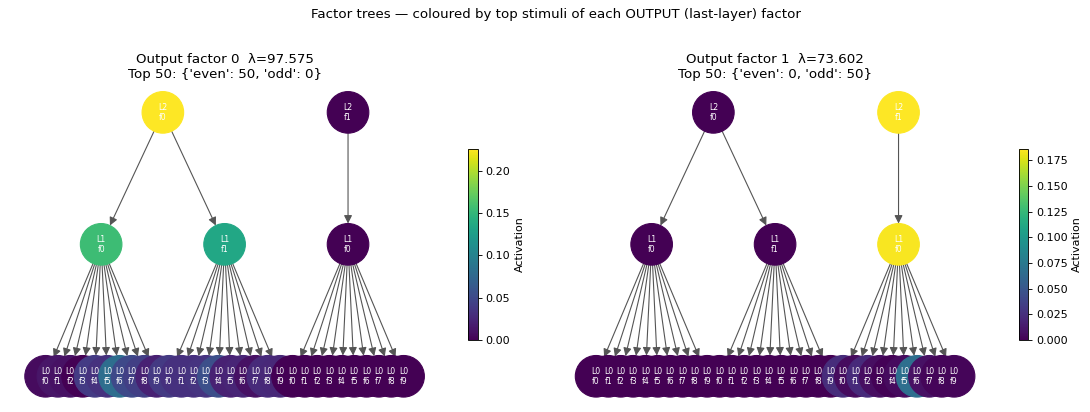

In [6]:
# ── 2a: Output (last-layer / root) factors ────────────────────────────────────
K_root = len(root_bft_node['lambdas'])
print(f'Plotting {K_root} output-layer factor trees ...')

fig, axes = plt.subplots(1, K_root, figsize=(7 * K_root, 5), squeeze=False)
axes = axes[0]

for k in range(K_root):
    acts, top_idx = top_stimuli_factor_activations(
        factor_nodes, root_bft_node, k, TOP_N_FACTOR
    )
    lam = root_bft_node['lambdas'][k]
    class_counts = {CLASS_NAMES.get(c, c): int((all_targets[top_idx] == c).sum())
                    for c in np.unique(all_targets)}
    plot_factor_tree(
        factor_nodes, acts, ax=axes[k],
        title=f'Output factor {k}  λ={lam:.3f}\nTop {len(top_idx)}: {class_counts}',
    )

plt.suptitle('Factor trees — coloured by top stimuli of each OUTPUT (last-layer) factor',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'tree_output_factors.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 3: Factor Fingerprints & Stimulus Similarity

Each stimulus is represented as the concatenation of `img_factors[s, :]` across **all** tree nodes (BFS order, all K factors per node).  Pairwise cosine similarity reveals how well the factor decomposition separates classes.

In [7]:
F = extract_fingerprint_matrix(tree_root, np.arange(n_samples))
expected_dim = sum(len(e['lambdas']) for e in tree_nodes)
print(f'Fingerprint matrix: {F.shape}   (Σ K_i = {expected_dim})')
assert F.shape[1] == expected_dim

Fingerprint matrix: (4078, 35)   (Σ K_i = 35)


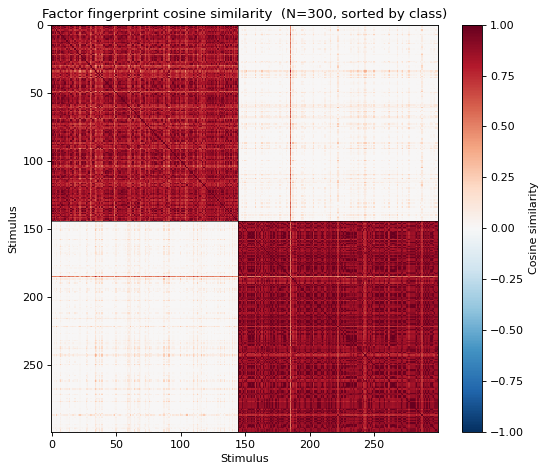

In [8]:
MAX_VIZ = 300
rng = np.random.default_rng(42)
if n_samples > MAX_VIZ:
    viz_idx = rng.choice(n_samples, MAX_VIZ, replace=False)
    viz_idx = viz_idx[np.argsort(all_targets[viz_idx])]
else:
    viz_idx = np.argsort(all_targets)

S = compute_stimulus_similarity(F[viz_idx])
targets_viz = all_targets[viz_idx]

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

for cl in np.unique(targets_viz):
    for b in np.where(np.diff((targets_viz == cl).astype(int)))[0]:
        ax.axhline(b + 0.5, color='k', lw=0.5, alpha=0.6)
        ax.axvline(b + 0.5, color='k', lw=0.5, alpha=0.6)

ax.set(title=f'Factor fingerprint cosine similarity  (N={len(viz_idx)}, sorted by class)',
       xlabel='Stimulus', ylabel='Stimulus')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_heatmap.png'), dpi=120, bbox_inches='tight')
plt.show()

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


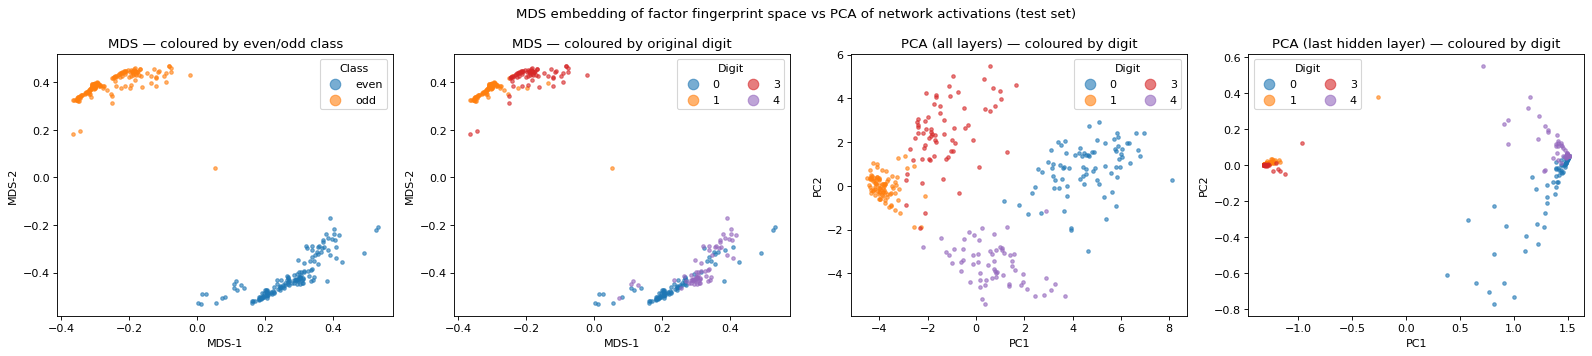

In [9]:
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA

dist_matrix = cosine_distances(F[viz_idx])
coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(dist_matrix)

# PCA over neurons — same stimuli as MDS
_li_sub  = np.hstack([l[viz_idx] for l in layer_inputs])
_li_last = layer_inputs[-2][viz_idx]
pca_all  = PCA(n_components=2).fit_transform(_li_sub)
pca_last = PCA(n_components=2).fit_transform(_li_last)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
cmap_tab = plt.get_cmap('tab10')

# Colour by class
for cl in sorted(np.unique(targets_viz)):
    mask = targets_viz == cl
    axes[0].scatter(coords[mask, 0], coords[mask, 1], c=[cmap_tab(cl % 10)],
                    s=10, alpha=0.6, label=CLASS_NAMES.get(cl, str(cl)))
axes[0].legend(markerscale=3, title='Class')
axes[0].set(title='MDS — coloured by even/odd class', xlabel='MDS-1', ylabel='MDS-2')

# Colour by original digit
digits_viz = all_digits[viz_idx]
for d in sorted(np.unique(digits_viz)):
    mask = digits_viz == d
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=[cmap_tab(d % 10)],
                    s=10, alpha=0.6, label=str(d))
axes[1].legend(markerscale=3, title='Digit', ncol=2)
axes[1].set(title='MDS — coloured by original digit', xlabel='MDS-1', ylabel='MDS-2')

# PCA — all layers, digit coloring
for d in sorted(np.unique(digits_viz)):
    mask = digits_viz == d
    axes[2].scatter(pca_all[mask, 0], pca_all[mask, 1], c=[cmap_tab(d % 10)],
                    s=10, alpha=0.6, label=str(d))
axes[2].legend(markerscale=3, title='Digit', ncol=2)
axes[2].set(title='PCA (all layers) — coloured by digit', xlabel='PC1', ylabel='PC2')

# PCA — last hidden layer, digit coloring
for d in sorted(np.unique(digits_viz)):
    mask = digits_viz == d
    axes[3].scatter(pca_last[mask, 0], pca_last[mask, 1], c=[cmap_tab(d % 10)],
                    s=10, alpha=0.6, label=str(d))
axes[3].legend(markerscale=3, title='Digit', ncol=2)
axes[3].set(title='PCA (last hidden layer) — coloured by digit', xlabel='PC1', ylabel='PC2')

plt.suptitle('MDS embedding of factor fingerprint space vs PCA of network activations (test set)', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'similarity_mds.png'), dpi=120, bbox_inches='tight')
plt.show()

Intra-class similarity: 0.846 ± 0.093
Inter-class similarity: 0.034 ± 0.057


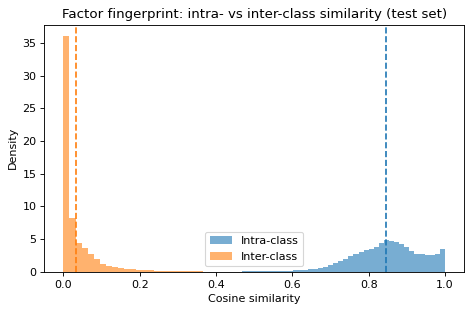

In [10]:
S_all = compute_stimulus_similarity(F)
classes = sorted(np.unique(all_targets))
intra_vals, inter_vals = [], []
for ci, cl in enumerate(classes):
    mask = all_targets == cl
    intra = S_all[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cl2 in classes[ci + 1:]:
        inter_vals.extend(S_all[np.ix_(mask, all_targets == cl2)].ravel())

intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class similarity: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class similarity: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=60, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=60, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--', lw=1.5)
ax.axvline(inter_arr.mean(), color='C1', ls='--', lw=1.5)
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra- vs inter-class similarity (test set)')
ax.legend()
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'intra_inter_stats.png'), dpi=120, bbox_inches='tight')
plt.show()

## Section 4: ID Sanity Check

Project **training** samples (digits 0,1,3,4 — same distribution as BFT) onto the fixed factors via NNLS and compare their tree activation patterns and fingerprints to the **test** samples.  If the factors are stable across train/test, the two should be nearly identical.

We compare even training vs even test and odd training vs odd test separately.

In [11]:
# Collect training layer inputs (correctly classified, same digit_filter as training)
data_train = collect_layer_inputs(
    model, train_loader.dataset,
    label_transform=label_transform, n_per_class=None, device=device,
)
train_images  = data_train['images']
train_targets = data_train['targets']
train_digits  = data_train['digits']
train_inputs  = data_train['layer_inputs']
print(f'Training samples: {len(train_images)}')
print(f'Class dist: {dict(zip(*np.unique(train_targets, return_counts=True)))}')

Training samples: 24450
Class dist: {np.int64(0): np.int64(11663), np.int64(1): np.int64(12787)}


In [12]:
# Project training samples onto the fixed BFT factors
projected_train_root  = project_stimuli_onto_tree(tree_root, train_inputs)
factor_nodes_train    = extract_factor_tree_nodes(projected_train_root)

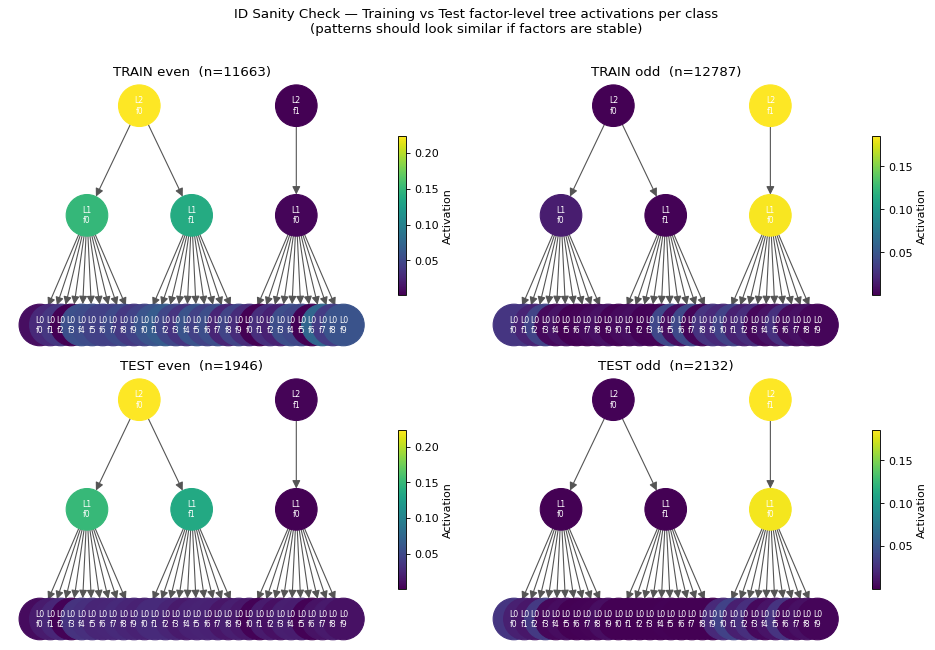

In [13]:
# ── Side-by-side tree: training class vs test class ───────────────────────────
fig, axes = plt.subplots(2, len(classes), figsize=(6 * len(classes), 8))

for col, cl in enumerate(classes):
    cl_name = CLASS_NAMES.get(cl, str(cl))

    # Training even/odd — use factor-level nodes so img_factors are read directly
    train_cl_idx = np.where(train_targets == cl)[0]
    acts_train = compute_factor_activations(factor_nodes_train, train_cl_idx)
    plot_factor_tree(factor_nodes_train, acts_train, ax=axes[0, col],
                     title=f'TRAIN {cl_name}  (n={len(train_cl_idx)})')

    # Test even/odd — use factor-level nodes from the original BFT tree
    test_cl_idx = np.where(all_targets == cl)[0]
    acts_test = compute_factor_activations(factor_nodes, test_cl_idx)
    plot_factor_tree(factor_nodes, acts_test, ax=axes[1, col],
                     title=f'TEST {cl_name}  (n={len(test_cl_idx)})')

plt.suptitle('ID Sanity Check — Training vs Test factor-level tree activations per class\n'
             '(patterns should look similar if factors are stable)', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_tree_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

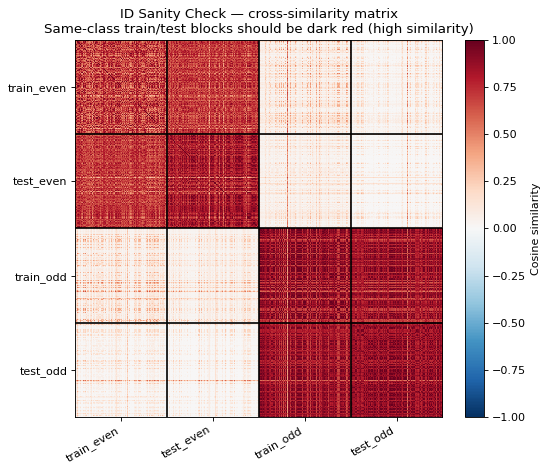

Mean cosine similarity per block pair:
                      train_even       test_even       train_odd        test_odd
      train_even           0.678           0.696           0.114           0.055
       test_even           0.696           0.806           0.081           0.037
       train_odd           0.114           0.081           0.831           0.829
        test_odd           0.055           0.037           0.829           0.867


In [14]:
# ── Fingerprint cross-similarity: train-even vs test-even vs train-odd vs test-odd ──
N_PER_SPLIT = 200   # cap per split for a readable heatmap

rng = np.random.default_rng(0)
classes = sorted(np.unique(all_targets))
splits = {}
for cl in classes:
    cl_name = CLASS_NAMES.get(cl, str(cl))

    tr_idx = np.where(train_targets == cl)[0]
    if len(tr_idx) > N_PER_SPLIT:
        tr_idx = rng.choice(tr_idx, N_PER_SPLIT, replace=False)
    splits[f'train_{cl_name}'] = extract_fingerprint_matrix(projected_train_root, tr_idx)

    te_idx = np.where(all_targets == cl)[0]
    if len(te_idx) > N_PER_SPLIT:
        te_idx = rng.choice(te_idx, N_PER_SPLIT, replace=False)
    splits[f'test_{cl_name}'] = extract_fingerprint_matrix(tree_root, te_idx)

split_labels = list(splits.keys())
F_blocks     = np.concatenate(list(splits.values()), axis=0)
block_sizes  = [len(v) for v in splits.values()]
block_starts = [0] + list(np.cumsum(block_sizes[:-1]))
block_ends   = list(np.cumsum(block_sizes))
boundaries   = np.array(block_ends[:-1])
S_cross      = compute_stimulus_similarity(F_blocks)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(S_cross, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')

for b in boundaries:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)

centres = np.array(block_starts) + np.array(block_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(split_labels, rotation=30, ha='right')
ax.set_yticks(centres); ax.set_yticklabels(split_labels)
ax.set_title('ID Sanity Check — cross-similarity matrix\n'
             'Same-class train/test blocks should be dark red (high similarity)')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_fingerprint_comparison.png'), dpi=120, bbox_inches='tight')
plt.show()

# Summary: mean similarity per block pair
print('Mean cosine similarity per block pair:')
header = ''.join(f'{l:>16}' for l in split_labels)
print(f'{"":>16}{header}')
for i, li in enumerate(split_labels):
    row_vals = []
    for j, lj in enumerate(split_labels):
        block = S_cross[block_starts[i]:block_ends[i], block_starts[j]:block_ends[j]]
        vals  = block[np.triu_indices_from(block, k=1)] if i == j else block.ravel()
        row_vals.append(f'{vals.mean():>16.3f}')
    print(f'{li:>16}' + ''.join(row_vals))

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


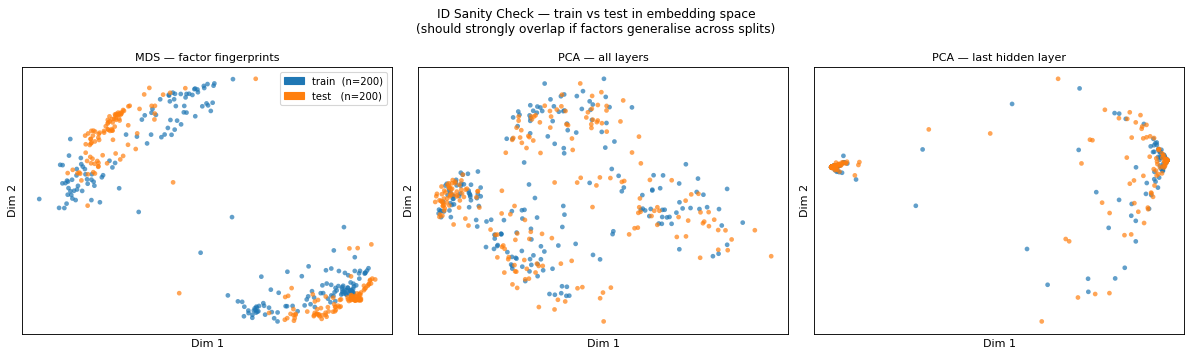

In [15]:
# ── MDS + PCA: training vs test colored by split (ID sanity check) ────────────
N_SAMPLE_ID = 200
rng_id = np.random.default_rng(42)

n_train_id = len(train_images)
tr_sub = rng_id.choice(n_train_id, min(N_SAMPLE_ID, n_train_id), replace=False)
te_sub = rng_id.choice(n_samples,  min(N_SAMPLE_ID, n_samples),  replace=False)
n_tr, n_te = len(tr_sub), len(te_sub)

# Factor fingerprints (train projected, test from original tree)
F_tr    = extract_fingerprint_matrix(projected_train_root, tr_sub)
F_te    = extract_fingerprint_matrix(tree_root, te_sub)
F_joint = np.concatenate([F_tr, F_te], axis=0)

# MDS on fingerprint cosine distances
coords_mds_id = MDS(n_components=2, dissimilarity='precomputed',
                    random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))

# PCA on raw layer activations (all layers concatenated)
li_joint_all = np.concatenate([
    np.hstack([l[tr_sub] for l in train_inputs]),
    np.hstack([l[te_sub] for l in layer_inputs]),
], axis=0)
pca_all_id = PCA(n_components=2).fit_transform(li_joint_all)

# PCA on last hidden layer only
li_joint_last = np.concatenate([train_inputs[-2][tr_sub], layer_inputs[-2][te_sub]], axis=0)
pca_last_id   = PCA(n_components=2).fit_transform(li_joint_last)

# Plot — blue = train, orange = test
colors = ['#1f77b4'] * n_tr + ['#ff7f0e'] * n_te
import matplotlib.patches as mpatches
legend_handles = [
    mpatches.Patch(color='#1f77b4', label=f'train  (n={n_tr})'),
    mpatches.Patch(color='#ff7f0e', label=f'test   (n={n_te})'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, coords, title in zip(
    axes,
    [coords_mds_id, pca_all_id, pca_last_id],
    ['MDS — factor fingerprints', 'PCA — all layers', 'PCA — last hidden layer'],
):
    ax.scatter(coords[:, 0], coords[:, 1], c=colors, s=18, alpha=0.7, linewidths=0)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
    ax.set_xticks([]); ax.set_yticks([])

axes[0].legend(handles=legend_handles, loc='best', fontsize=9)
plt.suptitle('ID Sanity Check — train vs test in embedding space\n'
             '(should strongly overlap if factors generalise across splits)', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'id_mds_pca_train_vs_test.png'), dpi=150, bbox_inches='tight')
plt.show()

## Section 5: Real OOD — digits excluded from training

The 0134 model was trained only on digits **0, 1, 3, 4**.  Here we load digits **2, 5, 6, 7, 8, 9** from the MNIST test set and project them onto the fixed BFT factors.  These digits were never seen during training, so how the network's factor decomposition handles them reveals the extent of generalisation.

`collect_layer_inputs_generic` (from `src.data_utils`) replaces the old `collect_inputs_no_filter` helper — use `only_correct=False` to collect all samples.

In [16]:
# Load full MNIST test set and filter to OOD digits
mnist_test_full = datasets.MNIST('../data/', train=False, download=False, transform=ToTensor())
all_mnist_labels = np.array(mnist_test_full.targets)
ood_indices = np.where(np.isin(all_mnist_labels, OOD_DIGITS))[0]
ood_subset  = Subset(mnist_test_full, ood_indices)

data_ood = collect_layer_inputs_generic(model, ood_subset,
                                        label_transform=label_transform,
                                        only_correct=False, device=device)
ood_images  = data_ood['images']
ood_digits  = data_ood['digits']
ood_targets = data_ood['targets']   # even/odd as seen by the model
ood_preds   = data_ood['preds']     # model predictions
ood_inputs  = data_ood['layer_inputs']

n_ood = len(ood_images)
ood_acc = (ood_preds == ood_targets).mean()
print(f'OOD samples      : {n_ood}')
print(f'OOD digits       : {OOD_DIGITS}')
print(f'Even/odd accuracy: {ood_acc:.3f}  (chance = 0.5)')
print(f'Digit breakdown  : {dict(zip(*np.unique(ood_digits, return_counts=True)))}')

OOD samples      : 5893
OOD digits       : [2, 5, 6, 7, 8, 9]
Even/odd accuracy: 0.409  (chance = 0.5)
Digit breakdown  : {np.int64(2): np.int64(1032), np.int64(5): np.int64(892), np.int64(6): np.int64(958), np.int64(7): np.int64(1028), np.int64(8): np.int64(974), np.int64(9): np.int64(1009)}


/var/folders/l6/mwg72rgn22bd0l2pn599jkch0000gn/T/ipykernel_11581/1431475252.py:3: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  all_mnist_labels = np.array(mnist_test_full.targets)


In [17]:
# Project OOD samples onto the fixed BFT factors via NNLS
projected_ood_root  = project_stimuli_onto_tree(tree_root, ood_inputs)
factor_nodes_ood    = extract_factor_tree_nodes(projected_ood_root)

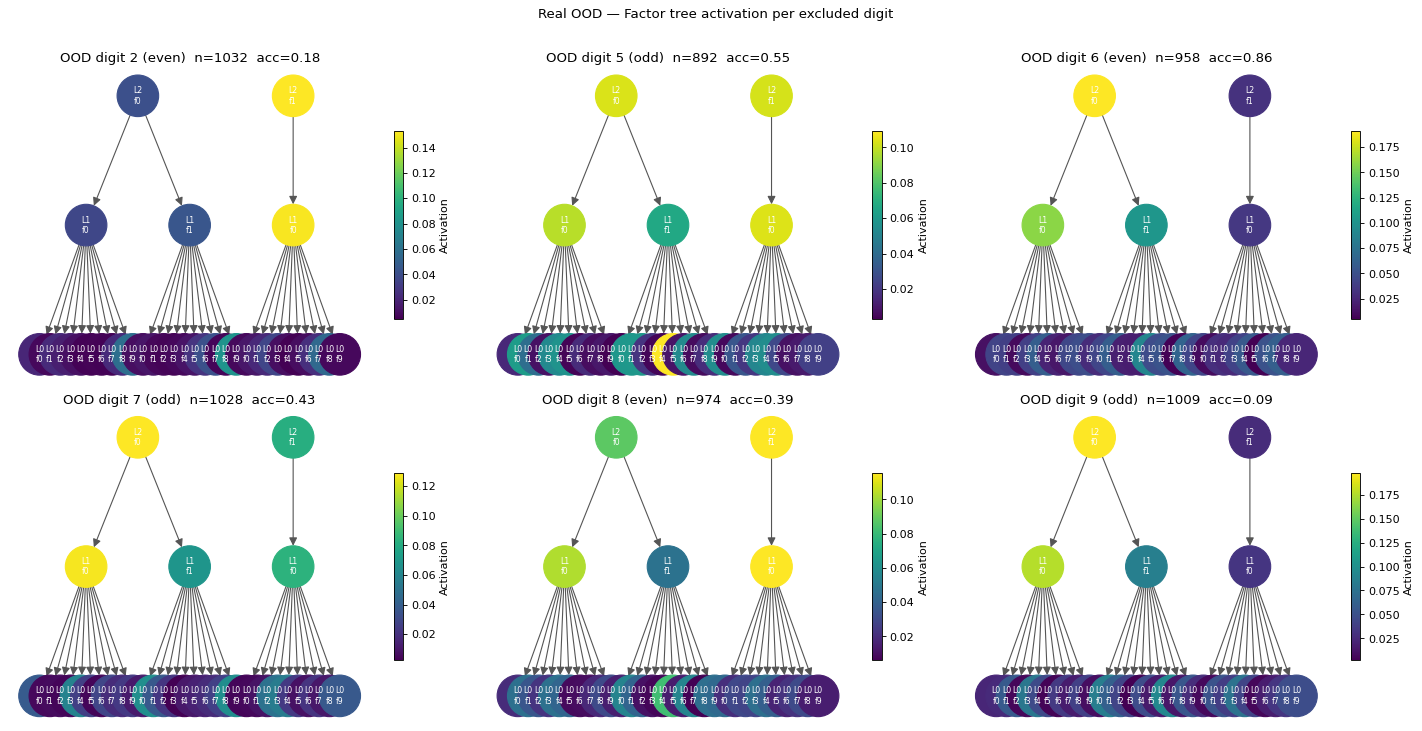

In [18]:
# ── Tree per OOD digit ────────────────────────────────────────────────────────
unique_ood = sorted(np.unique(ood_digits))
ncols = min(3, len(unique_ood))
nrows = int(np.ceil(len(unique_ood) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)

for i, d in enumerate(unique_ood):
    ax = axes[i // ncols][i % ncols]
    d_idx = np.where(ood_digits == d)[0]
    acts = compute_factor_activations(factor_nodes_ood, d_idx)
    parity = 'even' if d % 2 == 0 else 'odd'
    d_acc  = (ood_preds[d_idx] == ood_targets[d_idx]).mean()
    plot_factor_tree(
        factor_nodes_ood, acts, ax=ax,
        title=f'OOD digit {d} ({parity})  n={len(d_idx)}  acc={d_acc:.2f}',
    )

for j in range(len(unique_ood), nrows * ncols):
    axes[j // ncols][j % ncols].set_visible(False)

plt.suptitle('Real OOD — Factor tree activation per excluded digit', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_tree_per_digit.png'), dpi=120, bbox_inches='tight')
plt.show()

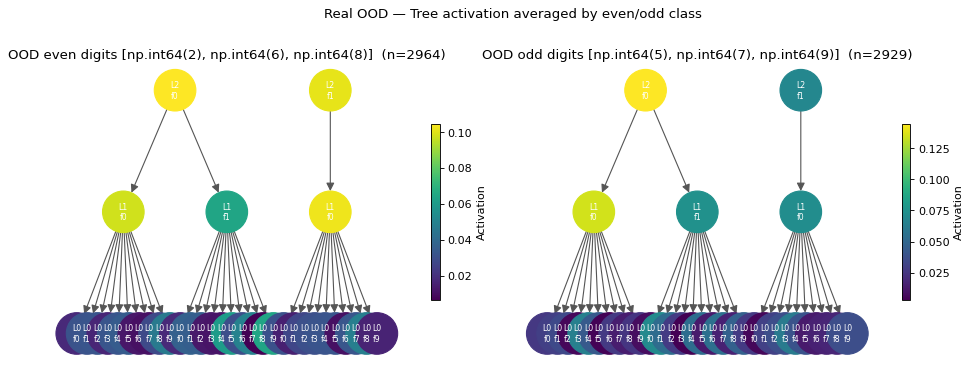

In [19]:
# ── Tree per even/odd class (OOD) ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, cl in zip(axes, sorted(np.unique(ood_targets))):
    cl_idx = np.where(ood_targets == cl)[0]
    acts = compute_factor_activations(factor_nodes_ood, cl_idx)
    digits_here = sorted(np.unique(ood_digits[cl_idx]))
    plot_factor_tree(
        factor_nodes_ood, acts, ax=ax,
        title=f'OOD {CLASS_NAMES.get(cl, cl)} digits {digits_here}  (n={len(cl_idx)})',
    )
plt.suptitle('Real OOD — Tree activation averaged by even/odd class', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_tree_per_class.png'), dpi=120, bbox_inches='tight')
plt.show()

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


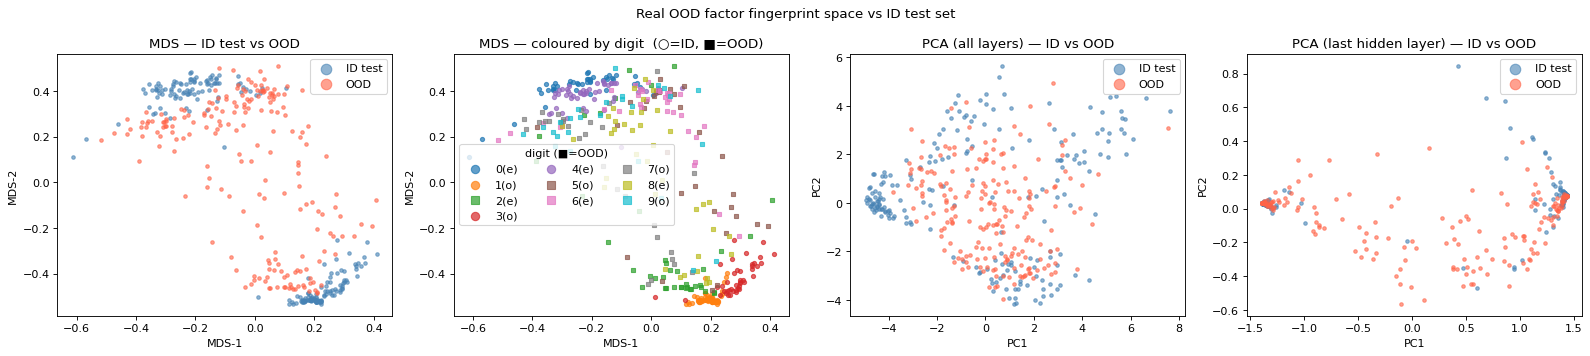

In [20]:
# ── MDS + PCA: ID test vs OOD digits in factor space ─────────────────────────
N_ID_SAMPLE  = 200
N_OOD_SAMPLE = min(200, n_ood)

rng = np.random.default_rng(1)
id_sub   = rng.choice(n_samples, N_ID_SAMPLE, replace=False)
ood_sub  = rng.choice(n_ood,     N_OOD_SAMPLE, replace=False)

F_id  = extract_fingerprint_matrix(tree_root, id_sub)
F_ood_sub = extract_fingerprint_matrix(projected_ood_root, ood_sub)
F_joint   = np.concatenate([F_id, F_ood_sub], axis=0)

coords = MDS(n_components=2, dissimilarity='precomputed', random_state=0, n_init=4).fit_transform(
    cosine_distances(F_joint)
)

# PCA over neurons for the same joint stimulus set
_n_joint = N_ID_SAMPLE + N_OOD_SAMPLE
_li_id   = np.hstack([l[id_sub]  for l in layer_inputs])
_li_ood  = np.hstack([l[ood_sub] for l in ood_inputs])
_li_joint_all  = np.vstack([_li_id,  _li_ood])
_li_joint_last = np.vstack([layer_inputs[-2][id_sub], ood_inputs[-2][ood_sub]])
pca_all  = PCA(n_components=2).fit_transform(_li_joint_all)
pca_last = PCA(n_components=2).fit_transform(_li_joint_last)

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
cmap_tab = plt.get_cmap('tab10')

# Left: ID vs OOD colouring (MDS)
axes[0].scatter(coords[:N_ID_SAMPLE, 0],  coords[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test')
axes[0].scatter(coords[N_ID_SAMPLE:, 0],  coords[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD')
axes[0].legend(markerscale=3)
axes[0].set(title='MDS — ID test vs OOD', xlabel='MDS-1', ylabel='MDS-2')

# Right: colour by digit (MDS)
joint_digits = np.concatenate([all_digits[id_sub], ood_digits[ood_sub]])
for d in sorted(np.unique(joint_digits)):
    mask = joint_digits == d
    parity = 'e' if d % 2 == 0 else 'o'
    marker = 'o' if d in TRAIN_DIGITS else 's'
    axes[1].scatter(coords[mask, 0], coords[mask, 1], c=[cmap_tab(d % 10)],
                    marker=marker, s=14, alpha=0.7, label=f'{d}({parity})')
axes[1].legend(markerscale=2, ncol=3, title='digit (■=OOD)')
axes[1].set(title='MDS — coloured by digit  (○=ID, ■=OOD)', xlabel='MDS-1', ylabel='MDS-2')

# PCA — all layers, ID/OOD colouring
axes[2].scatter(pca_all[:N_ID_SAMPLE, 0], pca_all[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test')
axes[2].scatter(pca_all[N_ID_SAMPLE:, 0], pca_all[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD')
axes[2].legend(markerscale=3)
axes[2].set(title='PCA (all layers) — ID vs OOD', xlabel='PC1', ylabel='PC2')

# PCA — last hidden layer, ID/OOD colouring
axes[3].scatter(pca_last[:N_ID_SAMPLE, 0], pca_last[:N_ID_SAMPLE, 1],
                c='steelblue', s=10, alpha=0.6, label='ID test')
axes[3].scatter(pca_last[N_ID_SAMPLE:, 0], pca_last[N_ID_SAMPLE:, 1],
                c='tomato',    s=10, alpha=0.6, label='OOD')
axes[3].legend(markerscale=3)
axes[3].set(title='PCA (last hidden layer) — ID vs OOD', xlabel='PC1', ylabel='PC2')

plt.suptitle('Real OOD factor fingerprint space vs ID test set', fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_fingerprint_mds.png'), dpi=120, bbox_inches='tight')
plt.show()

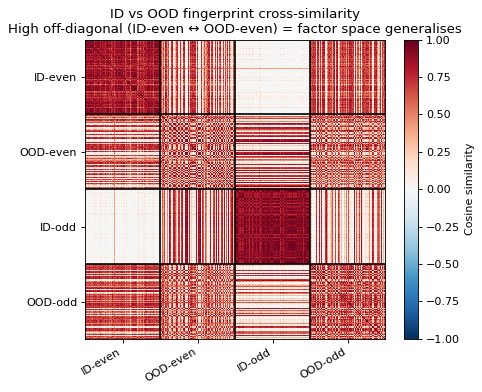

Mean cosine similarity per block pair:
                     ID-even      OOD-even        ID-odd       OOD-odd
       ID-even         0.811         0.410         0.030         0.569
      OOD-even         0.410         0.530         0.465         0.497
        ID-odd         0.030         0.465         0.884         0.284
       OOD-odd         0.569         0.497         0.284         0.593


In [21]:
# ── Block similarity: ID-even, ID-odd, OOD-even, OOD-odd ─────────────────────
N_BLOCK = 100
rng_block = np.random.default_rng(2)

blocks = {}
for cl in sorted(np.unique(all_targets)):
    cl_name = CLASS_NAMES.get(cl, str(cl))
    # ID test
    idx = rng_block.choice(np.where(all_targets == cl)[0],
                            min(N_BLOCK, (all_targets == cl).sum()), replace=False)
    blocks[f'ID-{cl_name}']  = extract_fingerprint_matrix(tree_root, idx)
    # OOD
    idx_ood = rng_block.choice(np.where(ood_targets == cl)[0],
                                min(N_BLOCK, (ood_targets == cl).sum()), replace=False)
    blocks[f'OOD-{cl_name}'] = extract_fingerprint_matrix(projected_ood_root, idx_ood)

block_labels  = list(blocks.keys())
F_all_blocks  = np.concatenate(list(blocks.values()), axis=0)
bl_sizes      = [len(v) for v in blocks.values()]
bl_starts     = [0] + list(np.cumsum(bl_sizes[:-1]))
bl_ends       = list(np.cumsum(bl_sizes))
bounds        = np.array(bl_ends[:-1])
S_blocks      = compute_stimulus_similarity(F_all_blocks)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(S_blocks, aspect='auto', interpolation='nearest', cmap='RdBu_r', vmin=-1, vmax=1)
fig.colorbar(im, ax=ax, label='Cosine similarity')
for b in bounds:
    ax.axhline(b - 0.5, color='k', lw=1.5)
    ax.axvline(b - 0.5, color='k', lw=1.5)
centres = np.array(bl_starts) + np.array(bl_sizes) / 2
ax.set_xticks(centres); ax.set_xticklabels(block_labels, rotation=30, ha='right')
ax.set_yticks(centres); ax.set_yticklabels(block_labels)
ax.set_title('ID vs OOD fingerprint cross-similarity\n'
             'High off-diagonal (ID-even ↔ OOD-even) = factor space generalises')
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'ood_cross_similarity.png'), dpi=120, bbox_inches='tight')
plt.show()

print('Mean cosine similarity per block pair:')
header = ''.join(f'{l:>14}' for l in block_labels)
print(f'{"":>14}{header}')
for i, li in enumerate(block_labels):
    row_vals = []
    for j in range(len(block_labels)):
        block = S_blocks[bl_starts[i]:bl_ends[i], bl_starts[j]:bl_ends[j]]
        vals  = block[np.triu_indices_from(block, k=1)] if i == j else block.ravel()
        row_vals.append(f'{vals.mean():>14.3f}')
    print(f'{li:>14}' + ''.join(row_vals))

## Section 5b: Far OOD — Synthetic images with no digit structure

Project images that look nothing like handwritten digits onto the fixed BFT factors.  If the factor tree is digit-specific, these should activate different branches or show near-zero loadings across the board.

Four types:
- **gaussian_noise** — i.i.d. pixels ~ N(0.5, 0.25²), clipped to [0,1]
- **uniform_gray** — constant mid-grey (all pixels = 0.5)
- **checkerboard** — hard 0/1 alternating pattern at pixel scale
- **inverted_test** — 1 − (test digit image): same structure, opposite contrast

In [22]:
from torch.utils.data import TensorDataset

N_FAR = 300   # stimuli per type
rng_f = np.random.default_rng(99)

_chk = (np.indices((IMAGE_SIDE, IMAGE_SIDE)).sum(axis=0) % 2).astype(np.float32)

far_ood_arrays = {
    'gaussian_noise': np.clip(
        rng_f.normal(0.5, 0.25, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).astype(np.float32), 0, 1),
    'uniform_gray':   np.full((N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE), 0.5, dtype=np.float32),
    'checkerboard':   np.broadcast_to(_chk, (N_FAR, 1, IMAGE_SIDE, IMAGE_SIDE)).copy().astype(np.float32),
    'inverted_test':  np.clip(1.0 - all_images[:N_FAR], 0, 1).astype(np.float32),
}

def collect_inputs_from_array(model, images_np, label_transform, device, batch_size=256):
    """Forward-pass a raw (N, C, H, W) float32 array through the model and return layer inputs."""
    dataset = TensorDataset(
        torch.from_numpy(images_np),
        torch.zeros(len(images_np), dtype=torch.long),
    )
    return collect_layer_inputs_generic(
        model, dataset, label_transform=label_transform,
        only_correct=False, device=device, batch_size=batch_size,
    )

far_ood_data = {}
for name, imgs in far_ood_arrays.items():
    d = collect_inputs_from_array(model, imgs, label_transform, device)
    d['projected_root'] = project_stimuli_onto_tree(tree_root, d['layer_inputs'])
    d['factor_nodes']   = extract_factor_tree_nodes(d['projected_root'])
    far_ood_data[name] = d
    acc = (d['preds'] == d['targets']).mean()
    print(f'{name:20s}  n={len(imgs)}  model acc={acc:.3f}')

gaussian_noise        n=300  model acc=0.000
uniform_gray          n=300  model acc=0.000
checkerboard          n=300  model acc=0.000
inverted_test         n=300  model acc=0.000


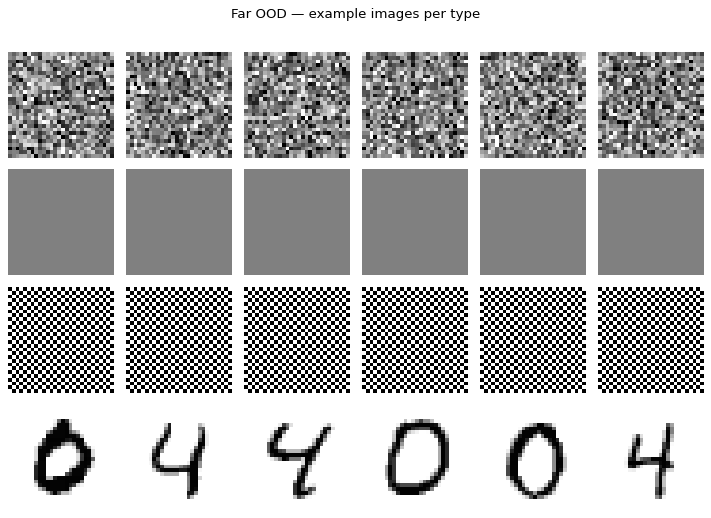

In [23]:
# ── Example images per far-OOD type ───────────────────────────────────────────
n_examples = 6
fig, axes = plt.subplots(len(far_ood_arrays), n_examples,
                          figsize=(n_examples * 1.5, len(far_ood_arrays) * 1.6))
for row, (name, imgs) in enumerate(far_ood_arrays.items()):
    for col in range(n_examples):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(name, fontsize=9, rotation=30, ha='right', va='center')
plt.suptitle('Far OOD — example images per type', y=1.01, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_examples.png'), dpi=120, bbox_inches='tight')
plt.show()

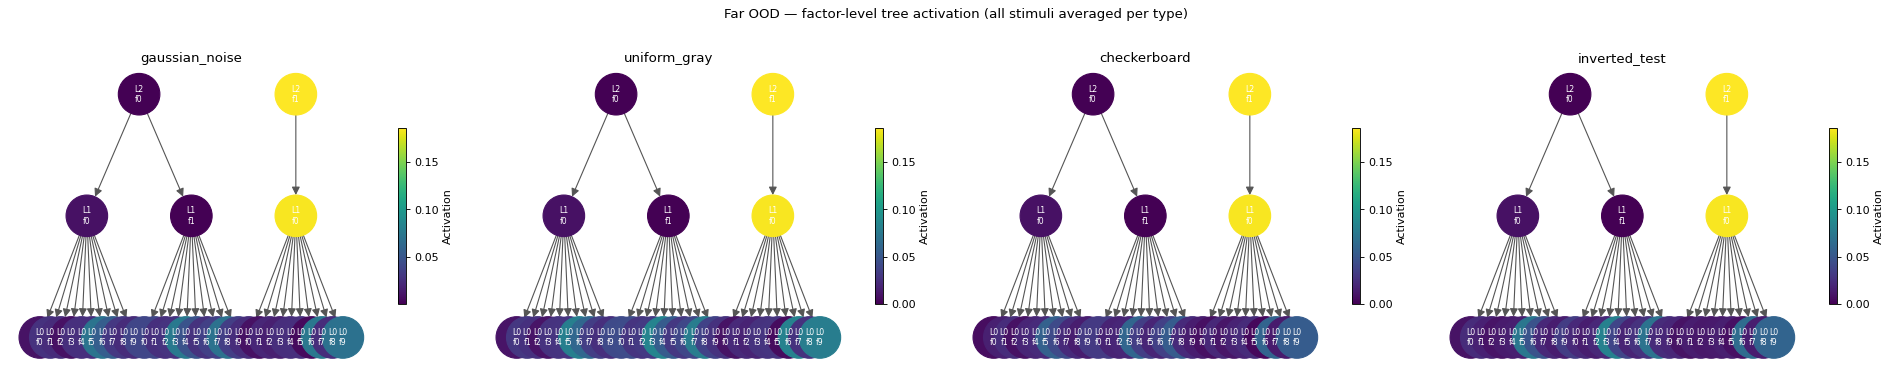

In [24]:
# ── Factor tree per far-OOD type ──────────────────────────────────────────────
n_types = len(far_ood_data)
fig, axes = plt.subplots(1, n_types, figsize=(6 * n_types, 4.5), squeeze=False)
axes = axes[0]

for ax, (name, d) in zip(axes, far_ood_data.items()):
    all_idx = np.arange(len(d['images']))
    acts    = compute_factor_activations(d['factor_nodes'], all_idx)
    plot_factor_tree(d['factor_nodes'], acts, ax=ax, title=name)

plt.suptitle('Far OOD — factor-level tree activation (all stimuli averaged per type)',
             y=1.02, fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_factor_tree.png'), dpi=120, bbox_inches='tight')
plt.show()

/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:771: FutureWarning: The `dissimilarity` parameter is deprecated and will be removed in 1.10. Use `metric` instead.
  warnings.warn(


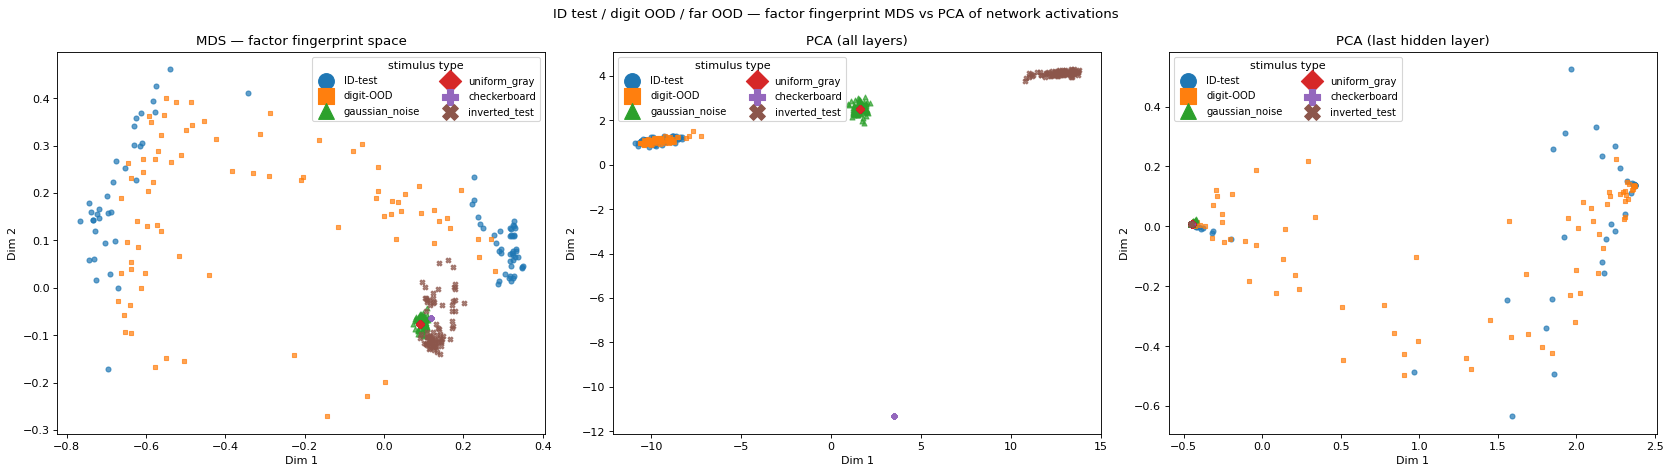

In [25]:
# ── MDS + PCA: ID test / digit OOD / far OOD in factor fingerprint space ──────
from sklearn.manifold import MDS
from sklearn.metrics.pairwise import cosine_distances
from sklearn.decomposition import PCA

N_EACH_MDS = 80
rng_m = np.random.default_rng(7)

F_parts, li_all_parts, li_last_parts = [], [], []
mds_labels, mds_markers = [], []

# ID test
id_sub = rng_m.choice(n_samples, min(N_EACH_MDS, n_samples), replace=False)
F_parts.append(extract_fingerprint_matrix(tree_root, id_sub))
li_all_parts.append(np.hstack([l[id_sub] for l in layer_inputs]))
li_last_parts.append(layer_inputs[-2][id_sub])
mds_labels  += ['ID-test'] * len(id_sub)
mds_markers += ['o'] * len(id_sub)

# Digit OOD
ood_sub = rng_m.choice(n_ood, min(N_EACH_MDS, n_ood), replace=False)
F_parts.append(extract_fingerprint_matrix(projected_ood_root, ood_sub))
li_all_parts.append(np.hstack([l[ood_sub] for l in ood_inputs]))
li_last_parts.append(ood_inputs[-2][ood_sub])
mds_labels  += ['digit-OOD'] * len(ood_sub)
mds_markers += ['s'] * len(ood_sub)

# Far OOD types
marker_cycle = ['^', 'D', 'P', 'X']
for (name, d), mkr in zip(far_ood_data.items(), marker_cycle):
    n = min(N_EACH_MDS, len(d['images']))
    sub = rng_m.choice(len(d['images']), n, replace=False)
    F_parts.append(extract_fingerprint_matrix(d['projected_root'], sub))
    li_all_parts.append(np.hstack([l[sub] for l in d['layer_inputs']]))
    li_last_parts.append(d['layer_inputs'][-2][sub])
    mds_labels  += [name] * n
    mds_markers += [mkr] * n

F_joint    = np.concatenate(F_parts, axis=0)
coords_mds = MDS(n_components=2, dissimilarity='precomputed',
                 random_state=0, n_init=4).fit_transform(cosine_distances(F_joint))
pca_all  = PCA(n_components=2).fit_transform(np.vstack(li_all_parts))
pca_last = PCA(n_components=2).fit_transform(np.vstack(li_last_parts))

unique_labels = list(dict.fromkeys(mds_labels))
cmap_tab = plt.get_cmap('tab10')
label_color  = {l: cmap_tab(i % 10) for i, l in enumerate(unique_labels)}
label_marker = dict(zip(mds_labels, mds_markers))

fig, axes = plt.subplots(1, 3, figsize=(21, 6))
for embed, ax, title in [
    (coords_mds, axes[0], 'MDS — factor fingerprint space'),
    (pca_all,    axes[1], 'PCA (all layers)'),
    (pca_last,   axes[2], 'PCA (last hidden layer)'),
]:
    for i, lbl in enumerate(mds_labels):
        ax.scatter(embed[i, 0], embed[i, 1],
                   c=[label_color[lbl]], marker=label_marker[lbl], s=20, alpha=0.7)
    for lbl in unique_labels:
        ax.scatter([], [], c=[label_color[lbl]], marker=label_marker[lbl], s=50, label=lbl)
    ax.legend(markerscale=2, ncol=2, fontsize=9, title='stimulus type')
    ax.set(title=title, xlabel='Dim 1', ylabel='Dim 2')

plt.suptitle('ID test / digit OOD / far OOD — factor fingerprint MDS vs PCA of network activations',
             fontsize=12)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'far_ood_mds.png'), dpi=120, bbox_inches='tight')
plt.show()